# scaling_train_size_2 — analysis

**Goal:** 

The trends found in `scaling_train_size` may not be reliable because the models did not train to convergence. Further, we have a better idea of what model parameters will perform best based on the results of `scaling_model_size`.


 I train models with 64 layers for 100k steps.


**Results:**

It appears like there is a preference for more data in general. However, I overloaded the GPU -> the top right corner is simply too much data to train with at once. The next step could be to train with batching.

However, the performance still seems to bottom out, possibly due to issues with precision? We will know based on the results of `scaling_model_3_double_precision`.

In [1]:
training_steps = 100_000 # 20_000
n_layers = 64 #10

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True


df = pd.read_parquet(Path('results') / 'summary.parquet')
df = df[df['training.steps'] == training_steps]
df = df[df['model.n_layers'] == n_layers]
df.head()


,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,timestamp,git_sha,git_dirty,hostname,platform,python_version,torch_version,gpu_name,cuda_version,run_id
0,1.5,8,32,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T00:27:00+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,5440483c99
1,1.5,8,128,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T04:00:59+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,8b9bcde524
2,1.5,8,512,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T07:06:49+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,facd7bb6e0
3,1.5,8,2056,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T10:25:47+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,02839e31cc
4,1.5,32,32,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T13:18:41+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,30f6d942e1


In [3]:
# df = df[df['training.steps'] == 200]
df

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,timestamp,git_sha,git_dirty,hostname,platform,python_version,torch_version,gpu_name,cuda_version,run_id
0,1.5,8,32,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T00:27:00+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,5440483c99
1,1.5,8,128,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T04:00:59+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,8b9bcde524
2,1.5,8,512,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T07:06:49+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,facd7bb6e0
3,1.5,8,2056,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T10:25:47+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,02839e31cc
4,1.5,32,32,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T13:18:41+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,30f6d942e1
5,1.5,32,128,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T16:27:24+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,aff192c55d
6,1.5,32,512,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-07T20:06:34+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,02e6d6ef51
7,1.5,32,2056,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-08T01:58:22+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,97c3108e22
8,1.5,128,32,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-08T05:01:52+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,9de29c9f73
9,1.5,128,128,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-05-08T08:18:16+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,NVIDIA TITAN Xp,12.1,d04849ca1a


In [4]:
# norbits = 'data.n_orbits'
# agg_norbits = df.groupby(norbits).agg(
#     final_loss_mean=('final_loss', 'mean'),
#     final_loss_std=('final_loss', 'std'),
#     eval_mean_error_max=('eval_mean_error_max', 'mean'),
#     eval_mean_error_max_std=('eval_mean_error_max', 'std'),
#     eval_max_error_mean=('eval_max_error_mean', 'mean'),
#     eval_max_error_max=('eval_max_error_max', 'max'),
#     wall_time_mean=('wall_time_s', 'mean'),
#     wall_time_std=('wall_time_s', 'std'),
# ).reset_index()
# agg_norbits

In [5]:
df['data.n_pts'] = df['data.n_orbits'] * df['data.n_steps']

# Training Evaluation

How well did the models train?

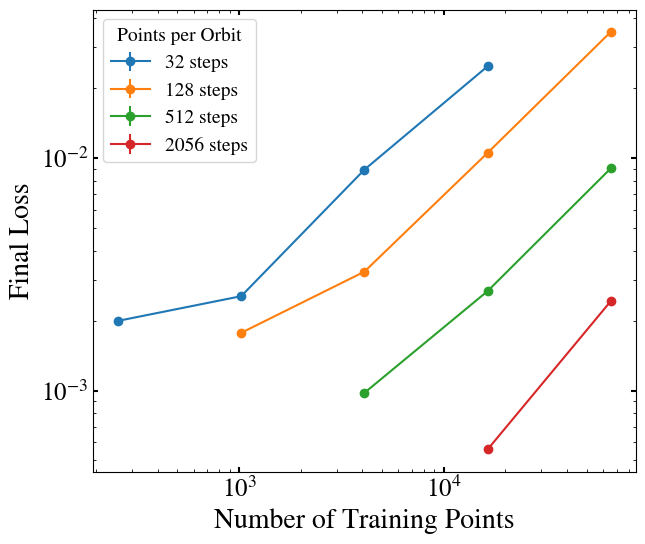

In [6]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.errorbar(subset['data.n_pts'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Training Points', fontsize=20)
plt.ylabel('Final Loss', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Points per Orbit')

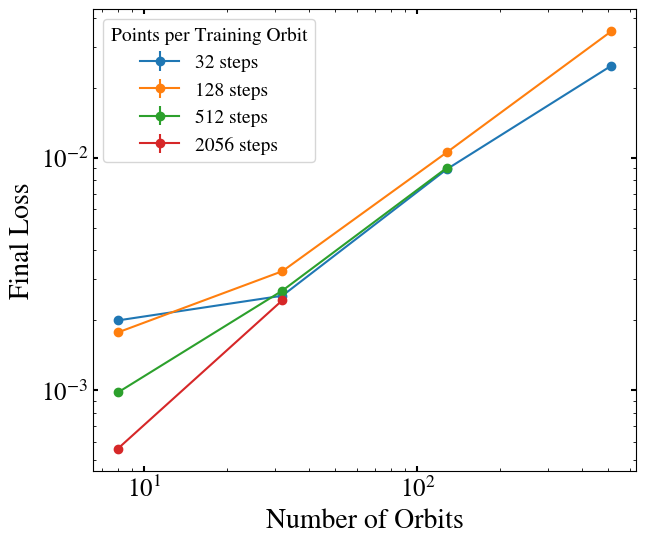

In [7]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Orbits', fontsize=20)
plt.ylabel('Final Loss', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Points per Training Orbit')

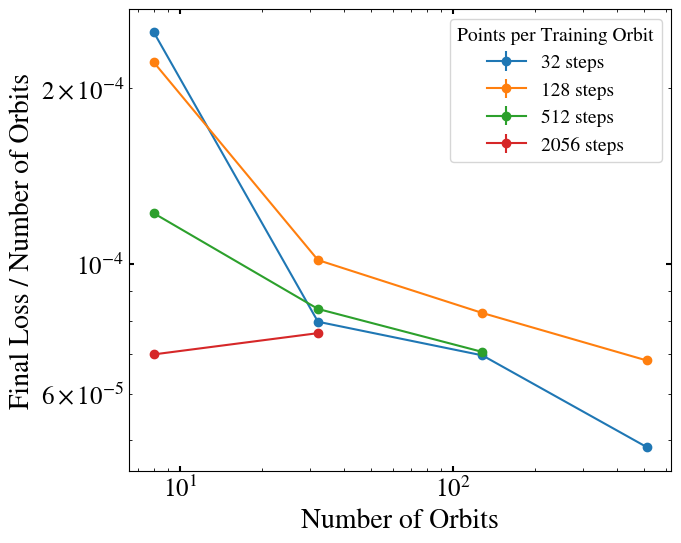

In [8]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss']/subset['data.n_orbits'], yerr=subset['tail_std_loss']/subset['data.n_orbits'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Orbits', fontsize=20)
plt.ylabel('Final Loss / Number of Orbits', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Points per Training Orbit')

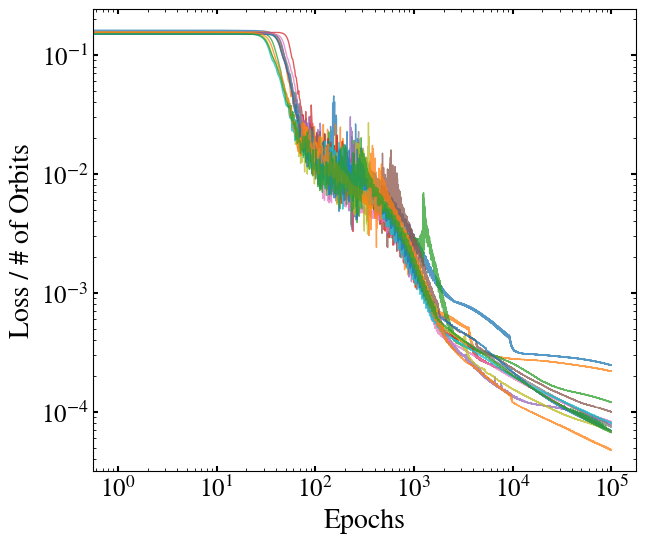

In [9]:
# from mat
plt.figure(figsize=(7, 6))

for n_orbits in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_orbits]
    for subset_id in subset['run_id']:
        filepath = Path('results') / 'runs'
        loss = np.load(filepath / subset_id / 'loss_curve.npy')
        plt.loglog(loss / n_orbits, lw=1, alpha=0.75)
    #plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss / # of Orbits', fontsize=20)
plt.yscale('log')
plt.xscale('log')

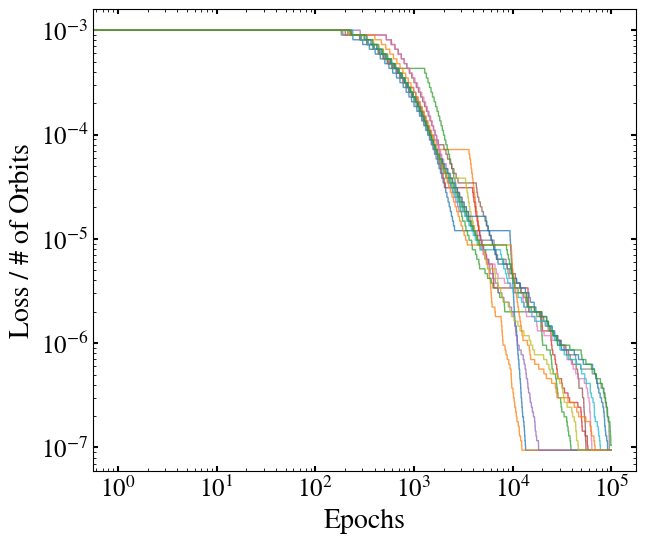

In [10]:
plt.figure(figsize=(7, 6))

for n_orbits in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_orbits]
    for subset_id in subset['run_id']:
        filepath = Path('results') / 'runs'
        lr = np.load(filepath / subset_id / 'lr_curve.npy')
        plt.loglog(lr, lw=1, alpha=0.75)
    #plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss / # of Orbits', fontsize=20)
plt.yscale('log')
plt.xscale('log')

In [11]:
# filepath = Path('results') / 'runs'
# plt.figure(figsize=(8,6))
# for rundir in filepath.iterdir():
#     loss = np.load(rundir/'loss_curve.npy')
#     plt.loglog(loss)
# plt.xlabel('Epochs')
# plt.ylabel('Loss')

# Performance Analysis

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_319304/1595531374.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.colorbar(pcm, label="$\\log_{10} \left ( \left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j} \\right )$")


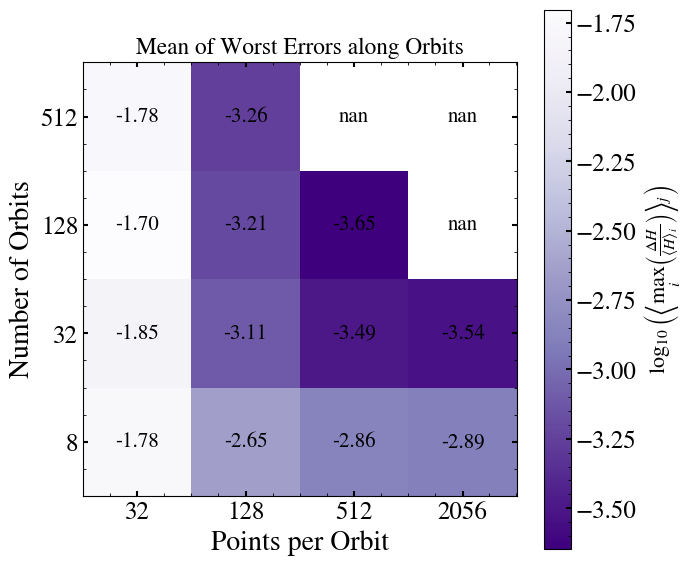

In [12]:
import numpy as np
import matplotlib.pyplot as plt

df_pivot = df.pivot(
    index='data.n_orbits',
    columns='data.n_steps',
    values='eval_max_error_mean'
)

x = df_pivot.columns.to_numpy()   # n_steps
y = df_pivot.index.to_numpy()     # n_orbits
z = np.log10(df_pivot.to_numpy())


x_plot = np.log2(x)
y_plot = np.log2(y)

fig, ax = plt.subplots(figsize=(7,7))

pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

ax.set_xticks(x_plot)
ax.set_xticklabels(x)

ax.set_yticks(y_plot)
ax.set_yticklabels(y)

ax.set_aspect('equal')

# Add text inside each cell
for i in range(len(y)):
    for j in range(len(x)):
        ax.text(
            x_plot[j],
            y_plot[i],
            f"{z[i, j]:.2f}",   # format to 2 decimals
            ha='center',
            va='center',
            fontsize=15
        )

fig.colorbar(pcm, label="$\\log_{10} \left ( \left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j} \\right )$")

plt.xlabel("Points per Orbit", fontsize=20)
plt.ylabel("Number of Orbits", fontsize=20)
plt.title('Mean of Worst Errors along Orbits')
plt.show()


### Worst Error of all points

$i$ = index of point along an orbit

$j$ = index of orbit

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_319304/1403522385.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)


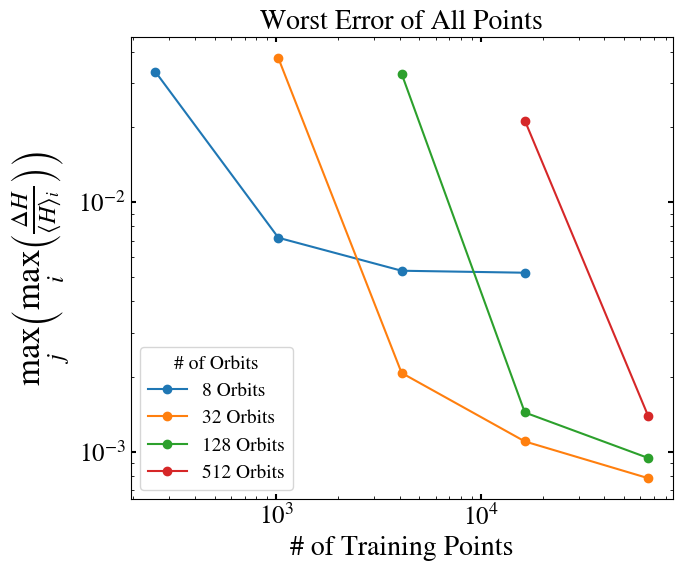

In [13]:
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_steps]
    plt.loglog(subset['data.n_pts'], subset['eval_max_error_max'], marker='o', label=f'{n_steps} Orbits')
plt.xlabel('# of Training Points', fontsize=20)
plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)
plt.legend(title='# of Orbits')
plt.title('Worst Error of All Points', fontsize=20)
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_319304/1403522385.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)


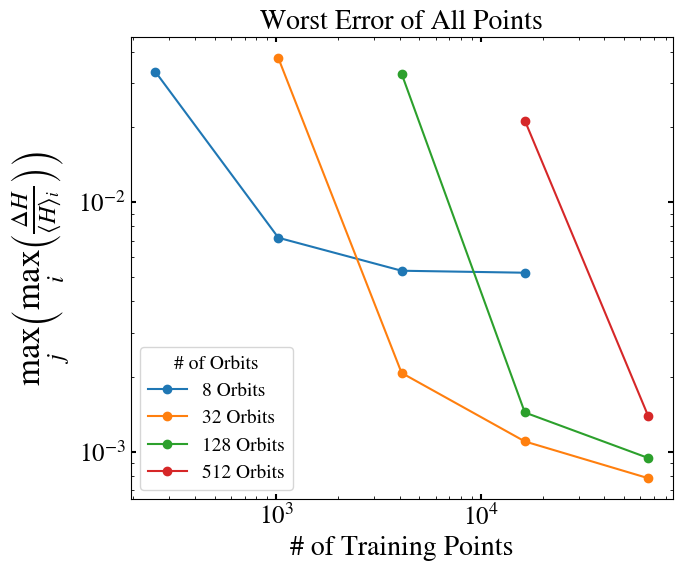

In [14]:
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_steps]
    plt.loglog(subset['data.n_pts'], subset['eval_max_error_max'], marker='o', label=f'{n_steps} Orbits')
plt.xlabel('# of Training Points', fontsize=20)
plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)
plt.legend(title='# of Orbits')
plt.title('Worst Error of All Points', fontsize=20)
plt.show()

### Mean of the average error along orbits

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_319304/2852673824.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)


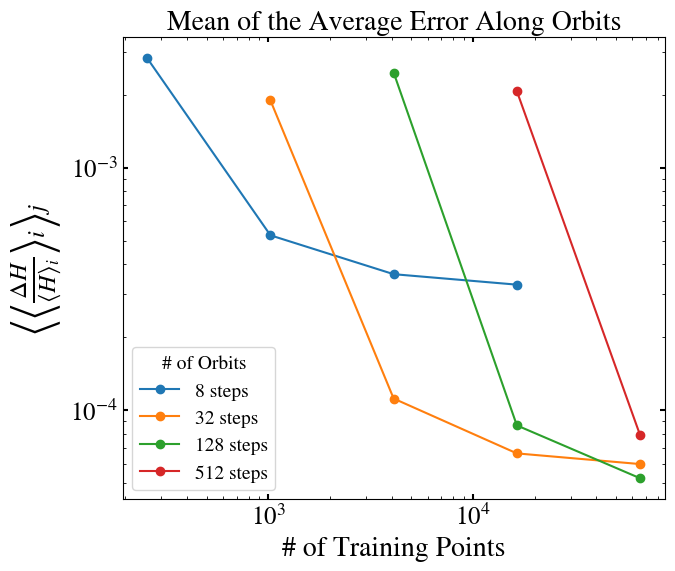

In [15]:
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_steps]
    plt.loglog(subset['data.n_pts'], subset['eval_mean_error_mean'], marker='o', label=f'{n_steps} steps')
plt.xlabel('# of Training Points', fontsize=20)
plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='# of Orbits')
plt.title('Mean of the Average Error Along Orbits', fontsize=20)
plt.show()

## Mean of the worst errors along orbits

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_319304/882786325.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)


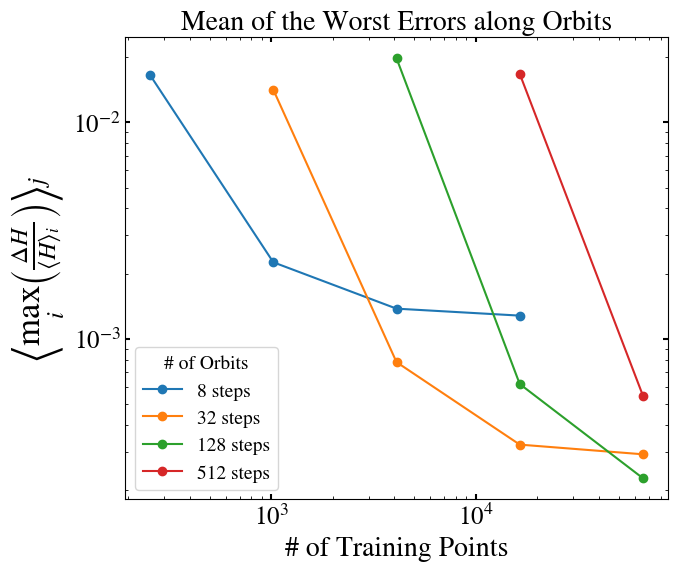

In [16]:
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_steps]
    plt.loglog(subset['data.n_pts'], subset['eval_max_error_mean'], marker='o', label=f'{n_steps} steps')
plt.xlabel('# of Training Points', fontsize=20)
plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='# of Orbits')
plt.title('Mean of the Worst Errors along Orbits', fontsize=20)
plt.show()

## Worst of the mean errors along orbits

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_319304/848662906.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)


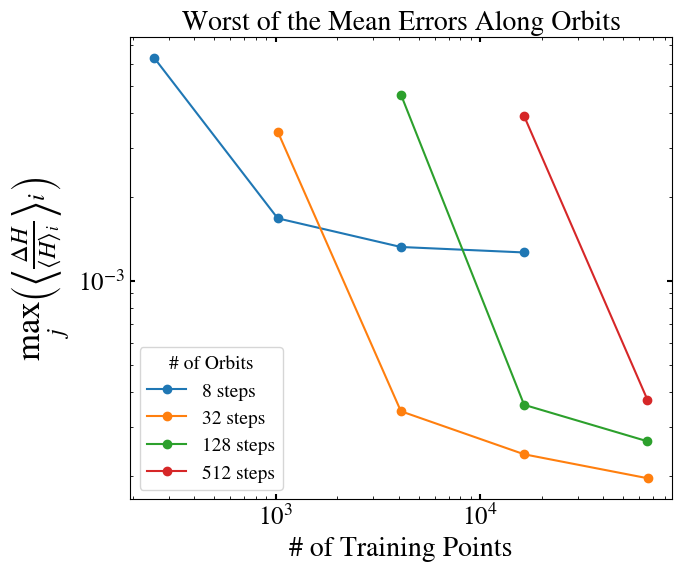

In [17]:
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_steps]
    plt.loglog(subset['data.n_pts'], subset['eval_mean_error_max'], marker='o', label=f'{n_steps} steps')
plt.xlabel('# of Training Points', fontsize=20)
plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)
plt.legend(title='# of Orbits')
plt.title('Worst of the Mean Errors Along Orbits', fontsize=20)
plt.show()